In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
import pandas as pd

df = pd.read_csv('steam_games_2026.csv')

In [10]:
df.head()

,AppID,Name,Release_Date,Primary_Genre,All_Tags,Price_USD,Discount_Pct,Review_Score_Pct,Total_Reviews,Steam_Deck_Status,Estimated_Owners,24h_Peak_Players
0,730,Counter-Strike 2,2012-08-21,Action,FPS;Shooter;Multiplayer;Competitive;Action;Tea...,0.00,0,83,4980365,Unknown,149410950,1013936
1,2868840,Slay the Spire 2,2026-03-05,Indie,Strategy;Roguelike;Card Game;Deckbuilding;Co-o...,24.99,0,97,49549,Unknown,1486470,0
2,3321460,Crimson Desert,2026-03-19,Action,Action;Open World;Singleplayer;Adventure;Comba...,69.99,0,0,0,Unknown,0,0
3,3065800,Marathon,2026-03-05,Action,Extraction Shooter;PvP;Multiplayer;Sci-fi;Shoo...,39.99,0,90,24360,Unknown,730800,0
4,3764200,Resident Evil Requiem,2026-02-26,Action,Survival Horror;Zombies;Horror;Third-Person Sh...,69.99,0,96,79667,Unknown,2390010,0


In [11]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   AppID              1000 non-null   int64  
 1   Name               1000 non-null   object 
 2   Release_Date       999 non-null    object 
 3   Primary_Genre      1000 non-null   object 
 4   All_Tags           986 non-null    object 
 5   Price_USD          1000 non-null   float64
 6   Discount_Pct       1000 non-null   int64  
 7   Review_Score_Pct   1000 non-null   int64  
 8   Total_Reviews      1000 non-null   int64  
 9   Steam_Deck_Status  1000 non-null   object 
 10  Estimated_Owners   1000 non-null   int64  
 11  24h_Peak_Players   1000 non-null   int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 93.9+ KB


,AppID,Price_USD,Discount_Pct,Review_Score_Pct,Total_Reviews,Estimated_Owners,24h_Peak_Players
count,1.000000e+03,1000.000000,1000.000000,1000.000000,1.000000e+03,1.000000e+03,1.000000e+03
mean,1.555769e+06,21.992930,18.145000,79.658000,6.387119e+04,1.916136e+06,5.213243e+03
std,1.070126e+06,18.812135,28.613716,19.382227,2.115879e+05,6.347638e+06,4.037537e+04
min,4.000000e+02,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.667775e+05,7.790000,0.000000,75.000000,1.638250e+03,4.914750e+04,0.000000e+00
50%,1.373235e+06,19.790000,0.000000,85.000000,1.173200e+04,3.519600e+05,2.865000e+02
75%,2.359555e+06,29.990000,35.000000,92.000000,4.851575e+04,1.455472e+06,1.601000e+03
max,4.206270e+06,69.990000,95.000000,100.000000,4.980365e+06,1.494110e+08,1.013936e+06


In [12]:
#vérification des valeurs manquantes
df.isnull().sum()

,0
AppID,0
Name,0
Release_Date,1
Primary_Genre,0
All_Tags,14
Price_USD,0
Discount_Pct,0
Review_Score_Pct,0
Total_Reviews,0
Steam_Deck_Status,0


In [14]:
df = df.dropna()

In [16]:
#les doublons
df.duplicated().sum()
df = df.drop_duplicates()

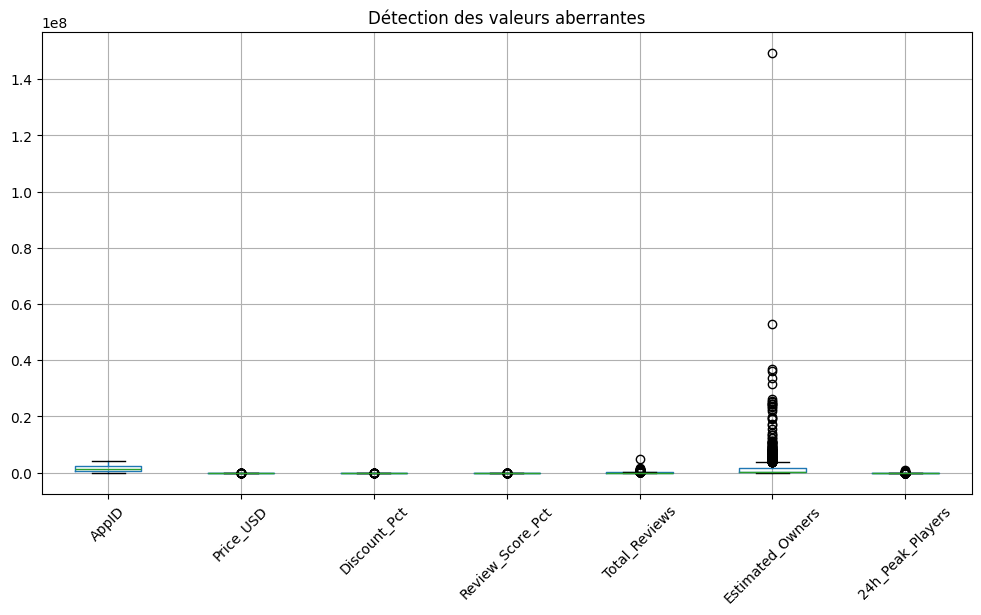

In [17]:
#outliers
# Example on numeric columns
df.select_dtypes(include=['float64', 'int64']).boxplot(figsize=(12,6))
plt.xticks(rotation=45)
plt.title("Détection des valeurs aberrantes")
plt.show()

In [18]:
#valeurs incohéence

for col in df.columns:
    print(col)
    print(df[col].unique()[:10])
    print("-----")

AppID
[    730 2868840 3321460 3065800 3764200 2157830 1144200 1172470 1808500
 2852190]
-----
Name
['Counter-Strike 2' 'Slay the Spire 2' 'Crimson Desert' 'Marathon'
 'Resident Evil Requiem' "John Carpenter's Toxic Commando" 'Ready or Not'
 'Apex Legends™' 'ARC Raiders'
 'Monster Hunter Stories 3: Twisted Reflection']
-----
Release_Date
['2012-08-21' '2026-03-05' '2026-03-19' '2026-02-26' '2026-03-12'
 '2023-12-13' '2020-11-04' '2025-10-30' '2022-04-21' '2024-06-13']
-----
Primary_Genre
['Action' 'Indie' 'Adventure' 'Casual' 'Sports' 'RPG' 'Simulation'
 'Unknown' 'Strategy' 'Racing']
-----
All_Tags
['FPS;Shooter;Multiplayer;Competitive;Action;Team-Based;eSports;Tactical;First-Person;PvP'
 'Strategy;Roguelike;Card Game;Deckbuilding;Co-op;Roguelike Deckbuilder;Card Battler;Turn-Based Combat;Multiplayer;Dungeon Crawler'
 'Action;Open World;Singleplayer;Adventure;Combat;Exploration;Dragons;Story Rich;Action-Adventure;Third Person'
 'Extraction Shooter;PvP;Multiplayer;Sci-fi;Shooter;FPS;Fu

In [19]:
#fréquence
for col in df.columns:
    print(f"\nFrequency for {col}:")
    print(df[col].value_counts().head())


Frequency for AppID:
AppID
917950     1
730        1
2868840    1
3321460    1
3065800    1
Name: count, dtype: int64

Frequency for Name:
Name
Vellum              1
Counter-Strike 2    1
Slay the Spire 2    1
Crimson Desert      1
Marathon            1
Name: count, dtype: int64

Frequency for Release_Date:
Release_Date
2026-03-12    12
2026-03-05    11
2019-01-24     8
2026-03-09     7
2025-10-23     7
Name: count, dtype: int64

Frequency for Primary_Genre:
Primary_Genre
Action       571
Adventure    101
Indie         73
RPG           69
Casual        63
Name: count, dtype: int64

Frequency for All_Tags:
All_Tags
Strategy;RPG;Indie    8
Action                7
Action;RPG;Indie      7
Action;Adventure      4
Action;RPG;FPS        3
Name: count, dtype: int64

Frequency for Price_USD:
Price_USD
19.99    103
0.00      97
29.99     75
39.99     69
59.99     61
Name: count, dtype: int64

Frequency for Discount_Pct:
Discount_Pct
0     645
50     59
60     44
20     26
75     23
Name: count,

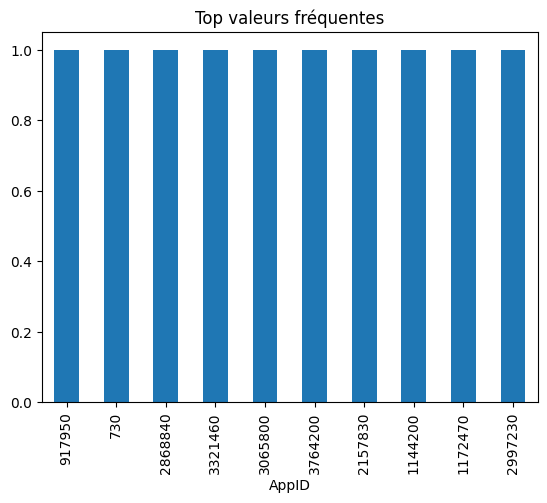

In [20]:
#visualisation

df.iloc[:,0].value_counts().head(10).plot(kind='bar')
plt.title("Top valeurs fréquentes")
plt.show()

In [29]:
df[num_cols].mean()
df[num_cols].median()
df[num_cols].std()
df[num_cols].quantile([0.25, 0.5, 0.75])



,AppID,Price_USD,Discount_Pct,Review_Score_Pct,Total_Reviews,Estimated_Owners,24h_Peak_Players
0.25,570940.0,7.99,0.0,75.0,1787.0,53610.0,0.0
0.50,1367550.0,19.99,0.0,85.0,11941.0,358230.0,291.0
0.75,2356560.0,29.99,35.0,92.0,49403.0,1482090.0,1600.0


In [31]:
df['Review_Score_Pct'].value_counts().head()

,count
Review_Score_Pct,
95,49
92,48
96,46
94,45
88,43


In [33]:
#proba
df['Review_Score_Pct'].value_counts(normalize=True).head()

,proportion
Review_Score_Pct,
95,0.049746
92,0.048731
96,0.046701
94,0.045685
88,0.043655


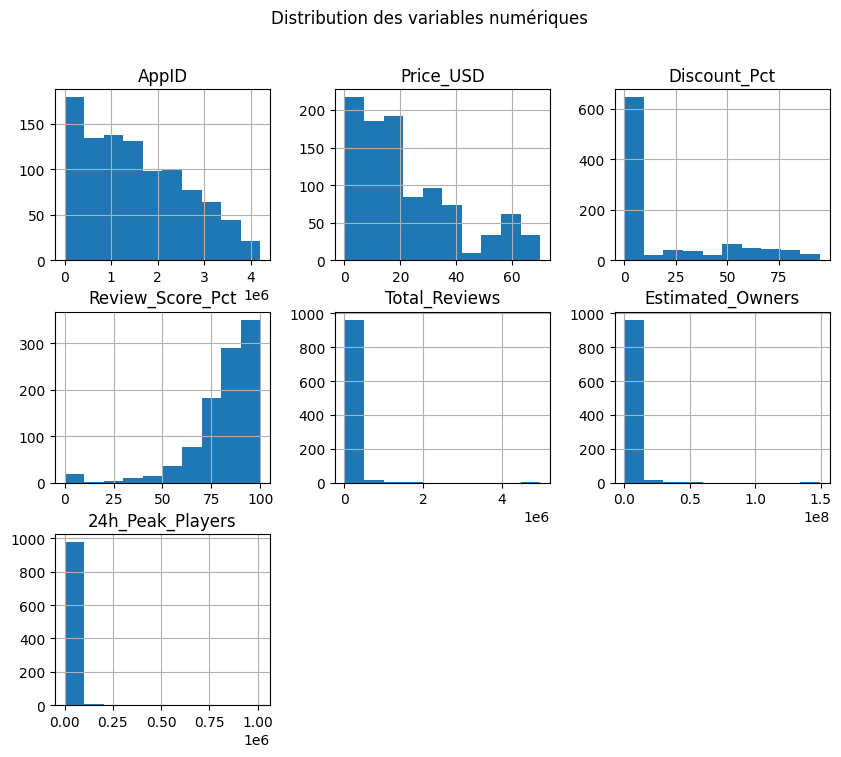

In [34]:
#visualisation
#histogramme
df[num_cols].hist(figsize=(10,8))
plt.suptitle("Distribution des variables numériques")
plt.show()

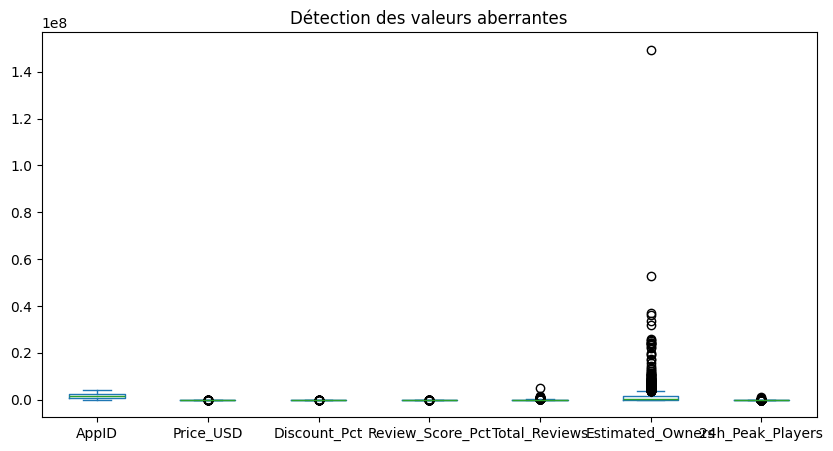

In [35]:
#boite à moustache
df[num_cols].plot(kind='box', figsize=(10,5))
plt.title("Détection des valeurs aberrantes")
plt.show()

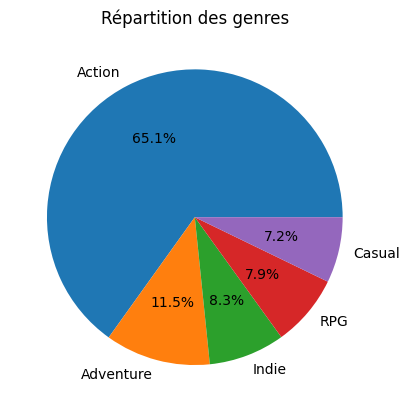

In [37]:
#diagamme circulaire
df['Primary_Genre'].value_counts().head(5).plot(kind='pie', autopct='%1.1f%%')
plt.title("Répartition des genres")
plt.ylabel('')
plt.show()

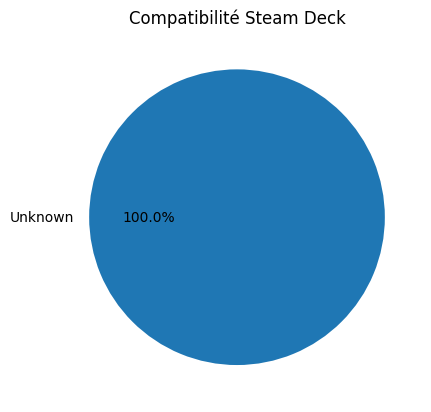

In [38]:
df['Steam_Deck_Status'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Compatibilité Steam Deck")
plt.ylabel('')
plt.show()

In [42]:
df['Release_Date'] = pd.to_datetime(df['Release_Date'], errors='coerce')

df['year'] = df['Release_Date'].dt.year

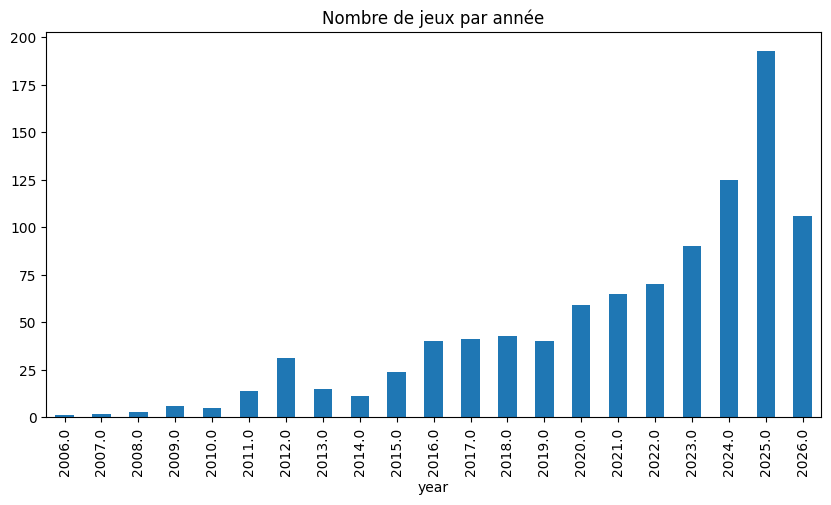

In [43]:
df['year'].value_counts().sort_index().plot(kind='bar', figsize=(10,5))
plt.title("Nombre de jeux par année")
plt.show()

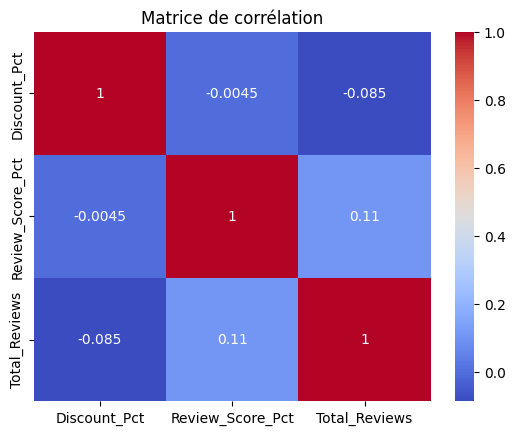

In [50]:
#corrélation entre variables quantétatives

import seaborn as sns
import matplotlib.pyplot as plt

num_cols = ['Discount_Pct', 'Review_Score_Pct', 'Total_Reviews']

corr = df[num_cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Matrice de corrélation")
plt.show()

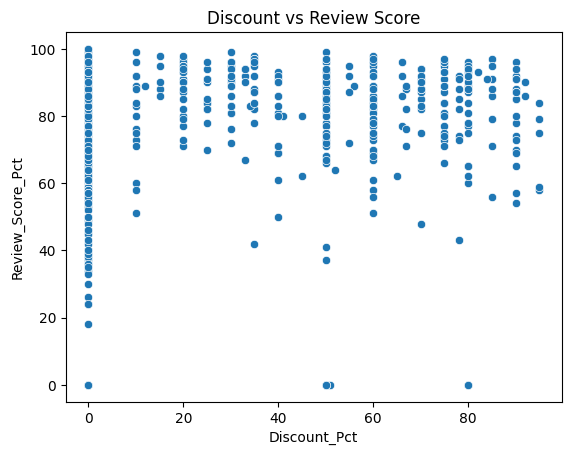

In [52]:
sns.scatterplot(x='Discount_Pct', y='Review_Score_Pct', data=df)
plt.title("Discount vs Review Score")
plt.show()

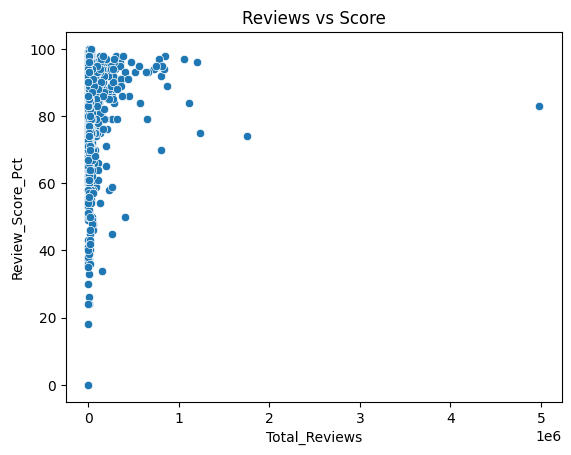

In [53]:
sns.scatterplot(x='Total_Reviews', y='Review_Score_Pct', data=df)
plt.title("Reviews vs Score")
plt.show()

qualitative vs quantitative

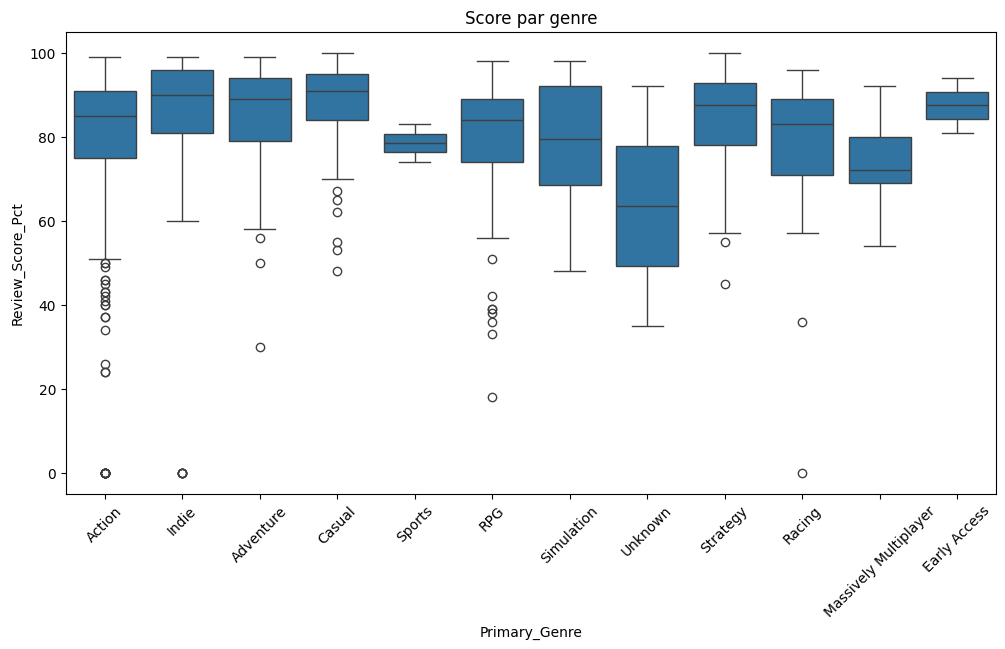

In [55]:
#genre vs score
plt.figure(figsize=(12,6))
sns.boxplot(x='Primary_Genre', y='Review_Score_Pct', data=df)
plt.xticks(rotation=45)
plt.title("Score par genre")
plt.show()


In [61]:
#tablaue croisé
pd.crosstab(df['Primary_Genre'], df['Steam_Deck_Status'])

Steam_Deck_Status,Unknown
Primary_Genre,
Action,571
Adventure,101
Casual,63
Early Access,2
Indie,73
Massively Multiplayer,13
RPG,69
Racing,17
Simulation,46


In [62]:
#Example: Probability that a game is “Compatible” GIVEN a genre
pd.crosstab(df['Primary_Genre'], df['Steam_Deck_Status'], normalize='index')

Steam_Deck_Status,Unknown
Primary_Genre,
Action,1.0
Adventure,1.0
Casual,1.0
Early Access,1.0
Indie,1.0
Massively Multiplayer,1.0
RPG,1.0
Racing,1.0
Simulation,1.0


In [64]:
#loi binomial
df['success'] = df['Review_Score_Pct'] > 80

df['success'].value_counts(normalize=True)

,proportion
success,
True,0.626396
False,0.373604


In [66]:
#théorème de byess
#score élevé
high_score = df['Review_Score_Pct'] > 80

#probabilité conditionelle
prob = df[high_score & (df['Primary_Genre'] == 'Action')].shape[0] / df[df['Primary_Genre'] == 'Action'].shape[0]

print(prob)

0.6007005253940455
